#TP M104 - Analyse Statistique des Performances Étudiantes

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df=pd.read_csv('/content/StudentsPerformance.csv')

In [37]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [38]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

##Exercice 1


In [39]:
scores = df[['math score', 'reading score', 'writing score']]
scores.head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [40]:
m = scores.mean()
med = scores.median()
mode = scores.mode()
print(m)
print(med)
print(mode)

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64
math score       66.0
reading score    70.0
writing score    69.0
dtype: float64
   math score  reading score  writing score
0          65             72             74


In [41]:
stats= pd.DataFrame({
    "Moyenne": m,
    "Mediane": med,
    "Mode": mode.iloc[0]
})

stats

,Moyenne,Mediane,Mode
math score,66.089,66.0,65
reading score,69.169,70.0,72
writing score,68.054,69.0,74


In [42]:
for col in scores.columns:
    m = scores[col].mean()
    med = scores[col].median()

    if abs(m - med) < 0.5:
        print(col, ": symétrique")
    elif m > med:
        print(col, ": asymétrie positive")
    else:
        print(col, ": asymétrie négative")


math score : symétrique
reading score : asymétrie négative
writing score : asymétrie négative


Nous avons calculé la moyenne, la médiane et le mode des scores en mathématiques, lecture et écriture.
Les valeurs de la moyenne et de la médiane sont globalement proches dans les trois matières, ce qui indique une distribution relativement symétrique.
Les modes représentent les scores les plus fréquents observés chez les étudiants.
>L’ensemble montre que les performances sont centrées autour de valeurs moyennes sans déséquilibre majeur.

##Exercice 2

In [43]:
scores.max() - scores.min()


,0
math score,100
reading score,83
writing score,90


L’étendue a été calculée comme la différence entre le score maximum et minimum.
La matière ayant la plus grande étendue présente la plus forte différence de performance entre les étudiants.
Cela indique une variabilité plus importante dans cette matière.

In [44]:

scores.var()
scores.std()

,0
math score,15.163080
reading score,14.600192
writing score,15.195657


La variance et l’écart-type mesurent la dispersion des scores autour de la moyenne.
Les matières avec un écart-type plus élevé montrent des scores plus hétérogènes.
Les résultats indiquent une dispersion modérée à forte selon la matière, ce qui signifie que les niveaux des étudiants sont variés

In [45]:
variance = scores.var()
std = scores.std()

s = pd.DataFrame({
    "Variance": variance,
    "Ecart_type": std})

s


,Variance,Ecart_type
math score,229.918998,15.163080
reading score,213.165605,14.600192
writing score,230.907992,15.195657


In [46]:
for col in scores.columns:
    if scores[col].std() < 15:
        print(col, "faible variabilité")
    else:
        print(col, "forte variabilité")

math score forte variabilité
reading score faible variabilité
writing score forte variabilité


##Exercice 3

In [47]:
quartiles = scores.quantile([0.25,0.5,0.75])
quartiles

,math score,reading score,writing score
0.25,57.0,59.0,57.75
0.50,66.0,70.0,69.00
0.75,77.0,79.0,79.00


Les quartiles divisent les scores en quatre groupes égaux.
Q1 représente les scores des 25% les plus faibles, Q2 correspond à la médiane, et Q3 aux 75%.
Cela permet de mieux comprendre la répartition des résultats.

In [48]:
IQR = quartiles.loc[0.75] - quartiles.loc[0.25]
IQR

,0
math score,20.00
reading score,20.00
writing score,21.25


In [49]:
Q1 = quartiles.loc[0.25]
Q3 = quartiles.loc[0.75]

In [50]:
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR


In [51]:
borne_inf

,0
math score,27.000
reading score,29.000
writing score,25.875


In [52]:
borne_sup

,0
math score,107.000
reading score,109.000
writing score,110.875


In [53]:
outliers = {}

for col in scores.columns:
    outliers[col] = df[
        (df[col] < borne_inf[col]) |
        (df[col] > borne_sup[col])
    ]

for col in outliers:
    print(col, ":", len(outliers[col]), "outliers")


math score : 8 outliers
reading score : 6 outliers
writing score : 5 outliers


Les scores situés en dehors de cet intervalle ont été considérés comme aberrants.
>Les résultats montrent la présence d’un nombre limité de valeurs aberrantes dans les trois matières.
Cela indique l’existence de quelques performances exceptionnellement faibles ou exceptionnellement élevées, mais leur faible nombre confirme que la distribution globale des scores reste stable et cohérente.

##Exercice 4

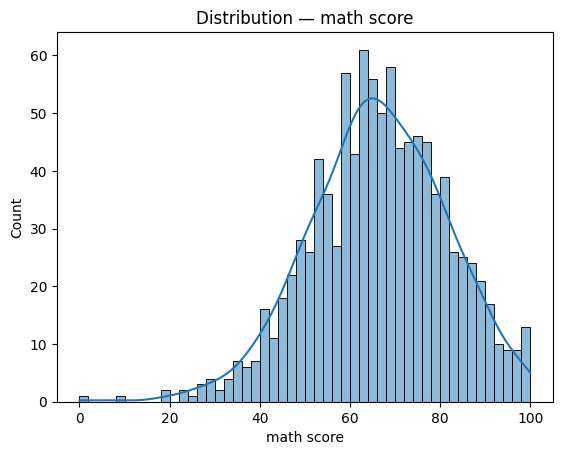

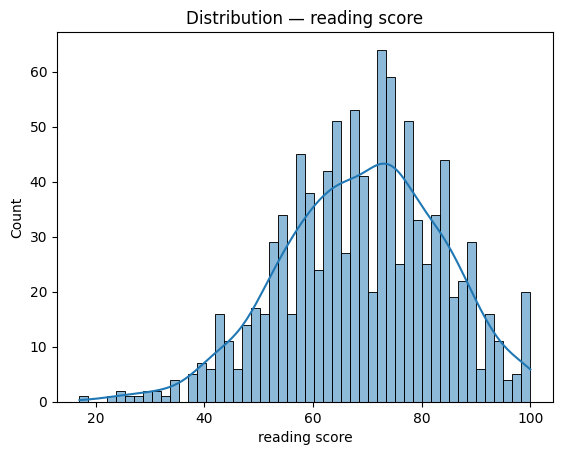

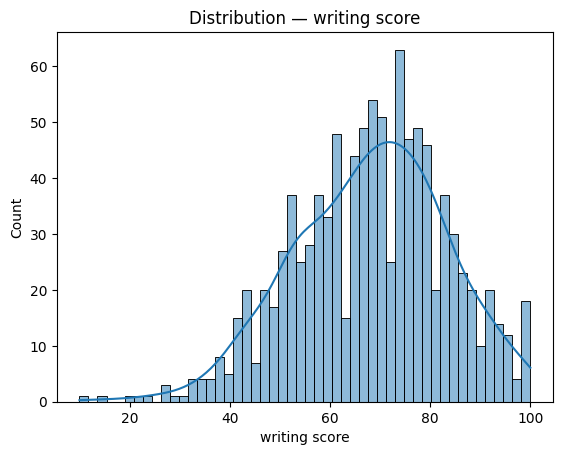

In [95]:
for col in scores.columns:
    sns.histplot(scores[col],bins=50,kde=True)
    plt.title(f"Distribution — {col}")
    plt.show()


Les histogrammes montrent des distributions proches d’une forme en cloche.
La majorité des étudiants ont des scores moyens, avec peu de valeurs extrêmes.

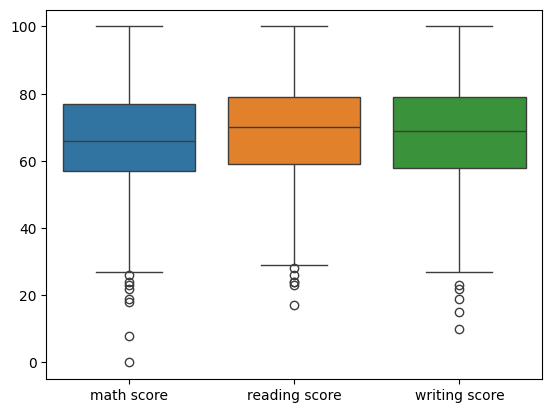

In [55]:
sns.boxplot(data=scores)
plt.show()


Les boîtes à moustaches montrent la dispersion et les quartiles.
Quelques points isolés confirment la présence de valeurs aberrantes.

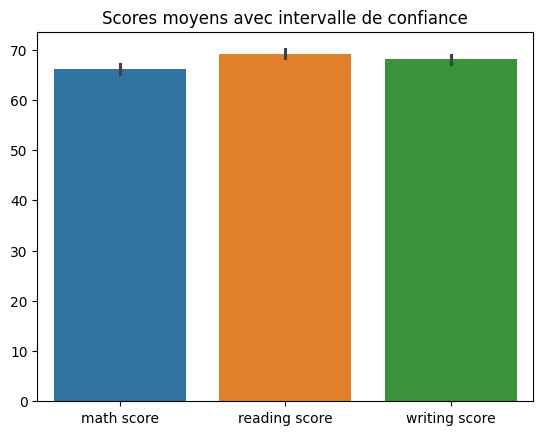

In [84]:

sns.barplot(data=scores, errorbar="ci")
plt.title("Scores moyens avec intervalle de confiance")
plt.show()


La comparaison des moyennes montre que les scores en lecture et écriture sont légèrement supérieurs aux scores en mathématiques.

##Exercice 5

In [57]:
cor = scores.corr()
cor


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


Corrélations attendues

Lecture ↔ Écriture
→ généralement très forte corrélation

Math ↔ Lecture
→ modérée à forte

Math ↔ Écriture
→ modérée

La corrélation entre lecture et écriture est forte, ce qui est logique car ces compétences sont liées.
Les corrélations entre mathématiques et les matières linguistiques sont modérées.
Cela montre une relation existante mais moins directe.

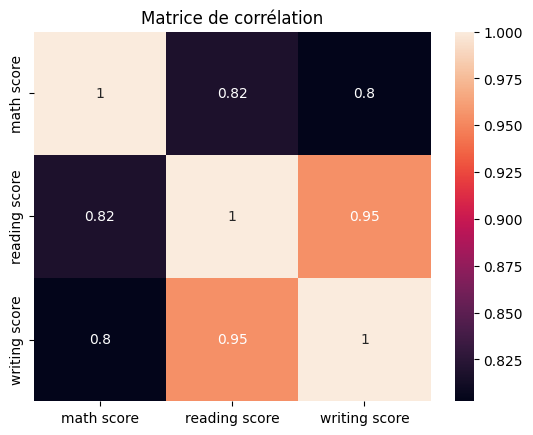

In [70]:
sns.heatmap(cor, annot=True)

plt.title("Matrice de corrélation")
plt.show()


| r         | Force   |
| --------- | ------- |
| 0.7 – 1.0 | Forte   |
| 0.4 – 0.7 | Modérée |
| 0.0 – 0.4 | Faible  |


In [59]:
df.groupby("parental level of education")[scores.columns].mean()


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


On observe que les étudiants dont les parents ont un niveau d’éducation plus élevé obtiennent en moyenne de meilleurs scores dans les trois matières.
La progression est globalement croissante avec le niveau d’études des parents.
>Cela suggère que l’environnement éducatif familial et le soutien académique à la maison ont une influence positive sur la performance scolaire.

In [60]:
df.groupby("lunch")[scores.columns].mean()


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


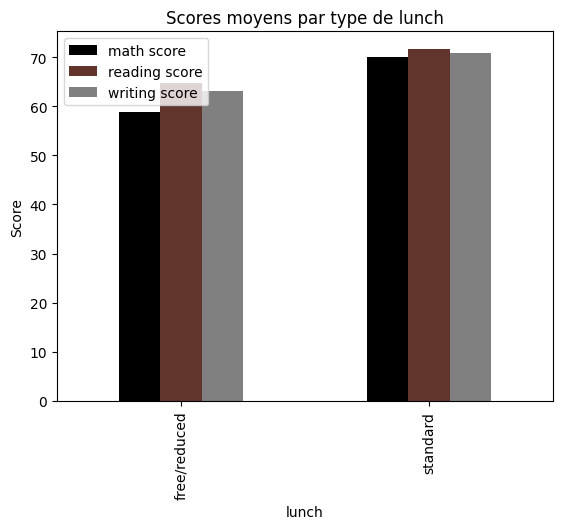

In [123]:
df.groupby("lunch")[scores.columns].mean() \
  .plot(kind="bar",color=["black", "#61342C", "grey"])

plt.title("Scores moyens par type de lunch")
plt.ylabel("Score")
plt.show()


Les étudiants ayant un lunch **standard** obtiennent des moyennes plus élevées que ceux ayant un lunch **free/reduced**.
>Cela indique un possible effet du statut socio-économique sur les performances académiques.
Les conditions de vie et d’accès aux ressources peuvent influencer les résultats scolaires.

In [61]:
df.groupby("test preparation course")[scores.columns].mean()


,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


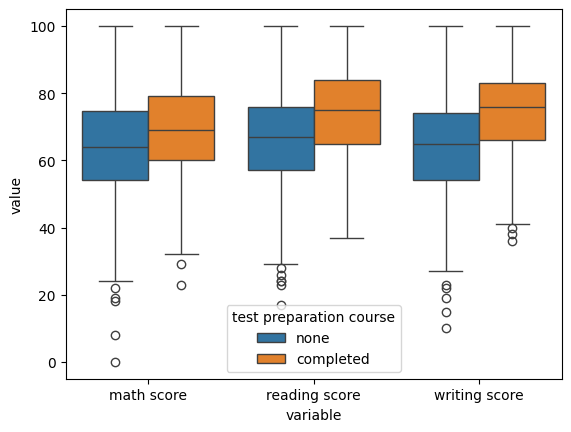

In [102]:
sns.boxplot(data=df.melt(
    id_vars="test preparation course",
    value_vars=scores.columns),
    x="variable",
    y="value",
    hue="test preparation course")
plt.show()


Les étudiants ayant suivi le cours de préparation au test obtiennent des scores moyens supérieurs dans toutes les matières.
L’écart est visible surtout en lecture et en écriture.
>Cela montre que la préparation ciblée améliore significativement la performance aux examens.

In [62]:
df.groupby("gender")[scores.columns].mean()


,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


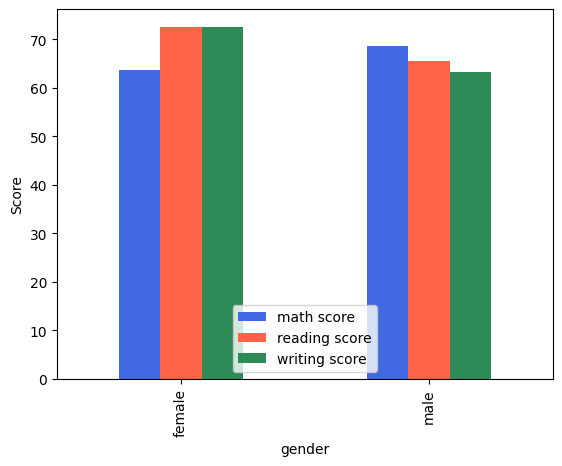

In [113]:
df.groupby("gender")[scores.columns].mean().plot(kind="bar",
      color=["royalblue", "tomato", "seagreen"])

plt.ylabel("Score")
plt.show()


On observe des différences de performance moyenne entre les genres selon la matière.
En général, les scores en lecture et écriture sont légèrement plus élevés chez **les filles**, tandis que les scores en mathématiques sont proches ou légèrement supérieurs chez **les garçons**.
>Ces écarts restent modérés mais montrent une variation par domaine de compétence.

In [63]:
df.groupby("race/ethnicity")[scores.columns].mean()


,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


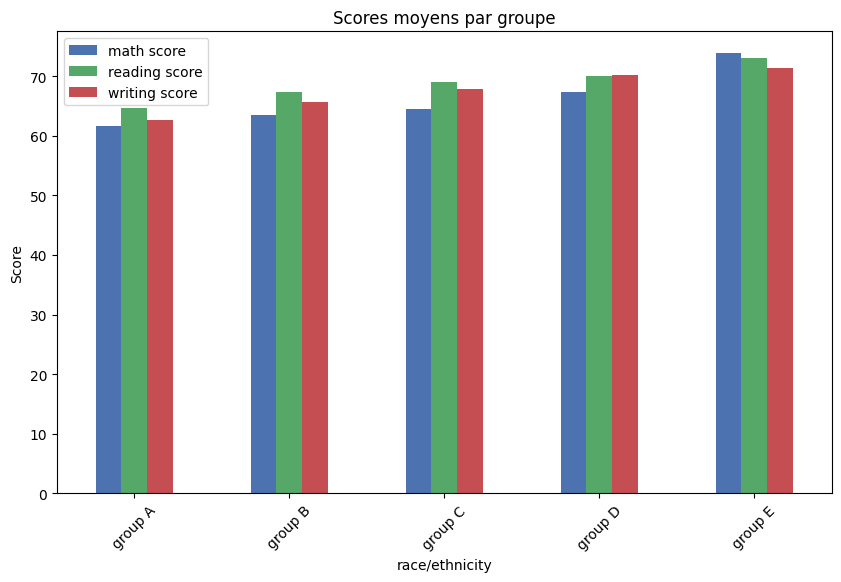

In [109]:
df.groupby("race/ethnicity")[scores.columns] \
  .mean() \
  .plot(kind="bar",
        figsize=(10,6),
        color=["#4C72B0", "#55A868", "#C44E52"])

plt.title("Scores moyens par groupe")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

Les moyennes varient selon les groupes, ce qui montre une diversité de performance entre populations.
Ces différences peuvent refléter des facteurs multiples : environnement éducatif, contexte socio-économique, accès aux ressources ou soutien scolaire.
>Cette variable doit être interprétée avec prudence car elle est descriptive et non causale.

Globalement, plusieurs facteurs externes — éducation parentale, statut socio-économique et préparation au test — montrent une influence mesurable sur les performances des étudiants.
La préparation académique et l’environnement familial apparaissent comme les facteurs les plus fortement associés à l’amélioration des scores